# Spam Ham Classification using Bag of Words and TF-IDF

1. Data Loading & EDA
2. Data Cleaning & Preprocessing (Lemmatization)
3. Train Test Split (Preventing Data Leakage)
4. Bag of Words Model (CountVectorizer)
5. TF-IDF Model (TfidfVectorizer)
6. Model Evaluation & Confusion Matrix

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = '../2. Text Pre-Processing/SMSSpam.txt' if os.path.exists('../2. Text Pre-Processing/SMSSpam.txt') else 'smsspamcollection/SMSSpamCollection'
messages = pd.read_csv(path, sep='\t', names=["label", "message"])

In [3]:
messages.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
messages.shape

(5572, 2)

In [5]:
## Class Distribution
messages['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

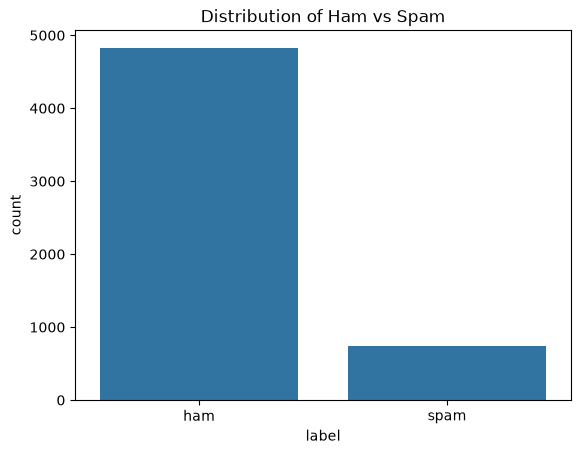

In [6]:
sns.countplot(x='label', data=messages)
plt.title('Distribution of Ham vs Spam')
plt.show()

In [7]:
## Feature Engineering: Length of message
messages['length'] = messages['message'].apply(len)
messages.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


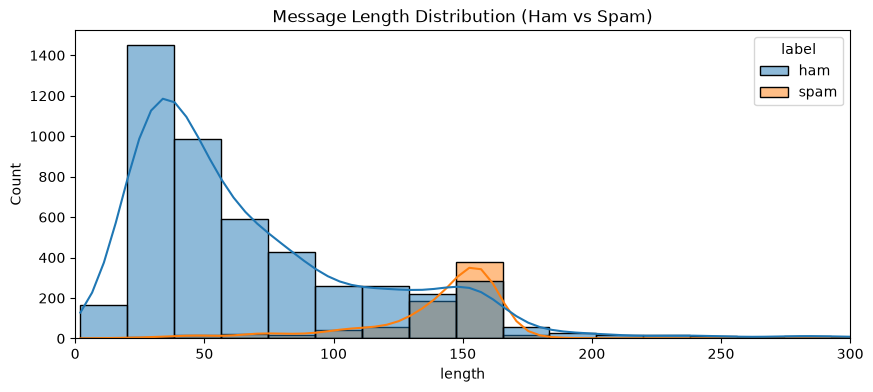

In [8]:
## Visualizing message length by label
plt.figure(figsize=(10, 4))
sns.histplot(x='length', hue='label', data=messages, bins=50, kde=True)
plt.xlim(0, 300)
plt.title('Message Length Distribution (Ham vs Spam)')
plt.show()

## Data Cleaning and Preprocessing

In [9]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [11]:
corpus = []
for i in range(0, len(messages)):
    review = re.sub('[^a-zA-Z]', ' ', messages['message'][i])
    review = review.lower()
    review = review.split()
    review = [lemmatizer.lemmatize(word) for word in review if word not in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)

In [12]:
corpus[0]

'go jurong point crazy available bugis n great world la e buffet cine got amore wat'

In [13]:
## Output Features
y = pd.get_dummies(messages['label'], drop_first=True)
y = y.values.ravel()

In [14]:
y.shape

(5572,)

## Train Test Split (Preventing Data Leakage)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(corpus, y, test_size=0.20, random_state=42)

In [16]:
len(X_train), len(X_test)

(4457, 1115)

## 1. Create Bag of Words Model

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=2500, ngram_range=(1, 2))

In [18]:
## Fit on train, transform on test to prevent data leakage
X_train_bow = cv.fit_transform(X_train).toarray()
X_test_bow = cv.transform(X_test).toarray()

In [19]:
X_train_bow.shape

(4457, 2500)

In [20]:
## Training MultinomialNB on Bag of Words
from sklearn.naive_bayes import MultinomialNB
spam_bow_model = MultinomialNB().fit(X_train_bow, y_train)

In [21]:
y_pred_bow = spam_bow_model.predict(X_test_bow)

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_score(y_test, y_pred_bow)

0.9847533632286996

In [23]:
print(classification_report(y_test, y_pred_bow))

              precision    recall  f1-score   support

       False       0.99      0.99      0.99       966
        True       0.95      0.94      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.98      0.98      0.98      1115



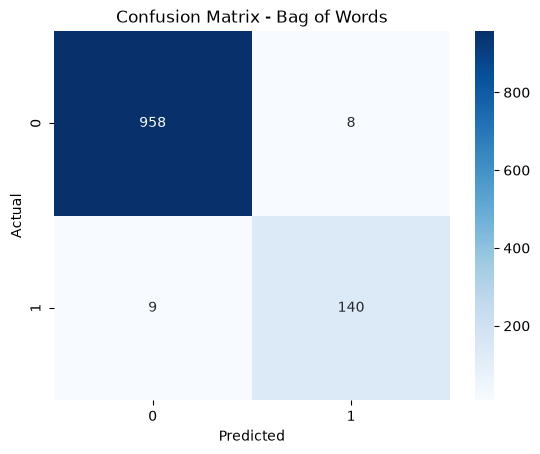

In [24]:
## Confusion Matrix for Bag of Words
sns.heatmap(confusion_matrix(y_test, y_pred_bow), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Bag of Words')
plt.show()

## 2. Create TF-IDF Model

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
tv = TfidfVectorizer(max_features=2500, ngram_range=(1, 2))

In [26]:
## Fit on train, transform on test to prevent data leakage
X_train_tfidf = tv.fit_transform(X_train).toarray()
X_test_tfidf = tv.transform(X_test).toarray()

In [27]:
X_train_tfidf.shape

(4457, 2500)

In [28]:
## Training MultinomialNB on TF-IDF
spam_tfidf_model = MultinomialNB().fit(X_train_tfidf, y_train)

In [29]:
y_pred_tfidf = spam_tfidf_model.predict(X_test_tfidf)

In [30]:
accuracy_score(y_test, y_pred_tfidf)

0.9811659192825112

In [31]:
print(classification_report(y_test, y_pred_tfidf))

              precision    recall  f1-score   support

       False       0.98      1.00      0.99       966
        True       0.98      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



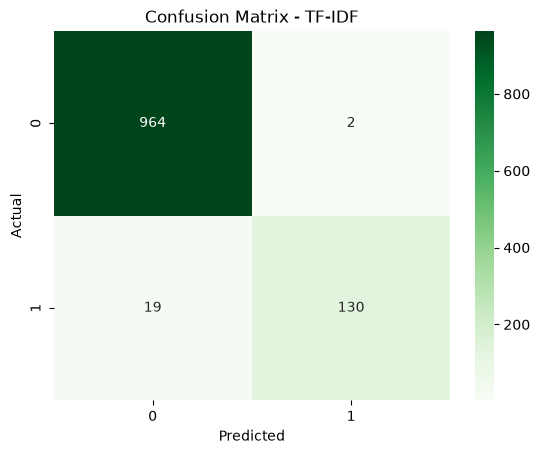

In [32]:
## Confusion Matrix for TF-IDF
sns.heatmap(confusion_matrix(y_test, y_pred_tfidf), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TF-IDF')
plt.show()